In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.insert(0, '../src')
from db import get_connection

conn = get_connection()
sns.set_theme(style='whitegrid')
print("Ready")

Ready


In [2]:
df = pd.read_sql("""
    SELECT
        p.full_name,
        pgs.*
    FROM player_game_stats pgs
    JOIN players p ON pgs.player_id = p.player_id
    ORDER BY pgs.player_id, pgs.game_date ASC
""", conn)

print(f"Shape: {df.shape}")
print(f"Players: {df['full_name'].nunique()}")
print(f"Date range: {df['game_date'].min()} → {df['game_date'].max()}")
df.head()

Shape: (4870, 21)
Players: 44
Date range: 2023-10-24 → 2025-04-13


/tmp/ipykernel_53892/1050984031.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("""


,full_name,id,player_id,game_id,game_date,season,matchup,home_away,minutes_played,points,...,assists,steals,blocks,turnovers,fg_attempted,fg_made,fg3_attempted,fg3_made,ft_attempted,ft_made
0,Nicolas Batum,2054,201587,0022300074,2023-10-25,22023,LAC vs. POR,home,9.0,0,...,1,1,1,0,0,0,0,0,0,0
1,Nicolas Batum,2053,201587,0022300085,2023-10-27,22023,LAC @ UTA,away,30.0,8,...,3,1,3,0,4,3,3,2,0,0
2,Nicolas Batum,2052,201587,0022300099,2023-10-29,22023,LAC vs. SAS,home,15.0,0,...,1,1,0,1,4,0,4,0,0,0
3,Nicolas Batum,2051,201587,0022300148,2023-11-06,22023,PHI vs. WAS,home,17.0,11,...,0,1,0,0,5,4,4,3,0,0
4,Nicolas Batum,2050,201587,0022300159,2023-11-08,22023,PHI vs. BOS,home,26.0,5,...,1,0,1,0,3,2,2,1,0,0


In [3]:
# Missing data audit

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
}).query('missing_count > 0')
print("Columns with missing data:")
print(missing_report if len(missing_report) > 0 else "None — clean dataset!")

Columns with missing data:
None — clean dataset!


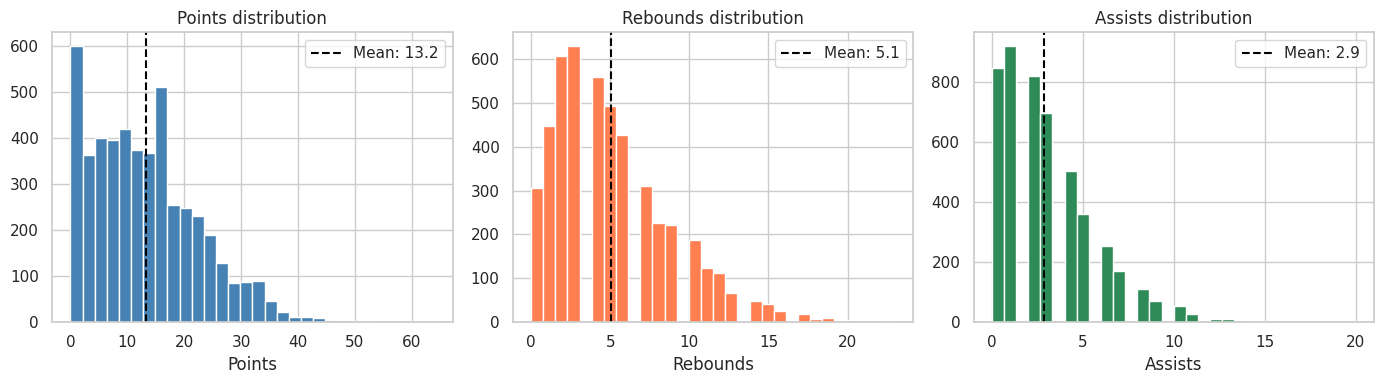

In [4]:
# Target variable distributions

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col, color in zip(axes, ['points', 'rebounds', 'assists'], ['steelblue', 'coral', 'seagreen']):
    ax.hist(df[col], bins=30, color=color, edgecolor='white')
    ax.axvline(df[col].mean(), color='black', linestyle='--', label=f"Mean: {df[col].mean():.1f}")
    ax.set_title(f'{col.capitalize()} distribution')
    ax.set_xlabel(col.capitalize())
    ax.legend()

plt.tight_layout()
plt.show()

In [5]:
for stat in ['points', 'rebounds', 'assists']:
    home = df[df['home_away'] == 'home'][stat].mean()
    away = df[df['home_away'] == 'away'][stat].mean()
    print(f"{stat:<10} — home: {home:.2f}  away: {away:.2f}  diff: {home - away:+.2f}")

points     — home: 13.28  away: 13.17  diff: +0.11
rebounds   — home: 5.14  away: 5.00  diff: +0.14
assists    — home: 2.89  away: 2.87  diff: +0.01


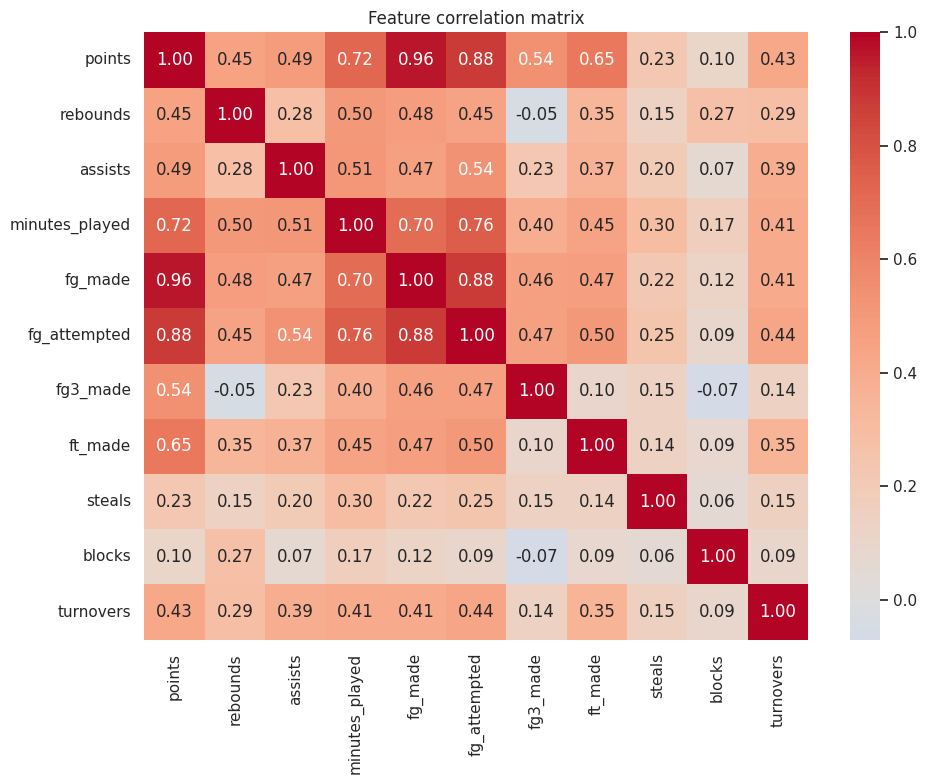

In [6]:
numeric_cols = ['points', 'rebounds', 'assists', 'minutes_played',
                'fg_made', 'fg_attempted', 'fg3_made', 'ft_made', 'steals', 'blocks', 'turnovers']
corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature correlation matrix')
plt.tight_layout()
plt.show()

In [7]:
# Player consistency (std dev of points)

consistency = df.groupby('full_name')['points'].agg(['mean', 'std', 'count'])
consistency.columns = ['avg_pts', 'std_pts', 'games']
consistency = consistency[consistency['games'] >= 20].sort_values('std_pts')
print("Most consistent scorers (lowest std dev):")
print(consistency.head(10).round(2))

Most consistent scorers (lowest std dev):
                        avg_pts  std_pts  games
full_name                                      
Thanasis Antetokounmpo     0.94     1.50     34
Trey Alexander             1.33     1.83     24
Steven Adams               3.88     3.40     58
Kyle Anderson              6.16     3.79    140
Nicolas Batum              4.59     4.00    138
Bismack Biyombo            4.68     4.01     68
Charles Bassey             4.00     4.16     55
Lonzo Ball                 7.63     4.20     35
Dominick Barlow            4.29     4.29     68
Goga Bitadze               6.16     5.11    132


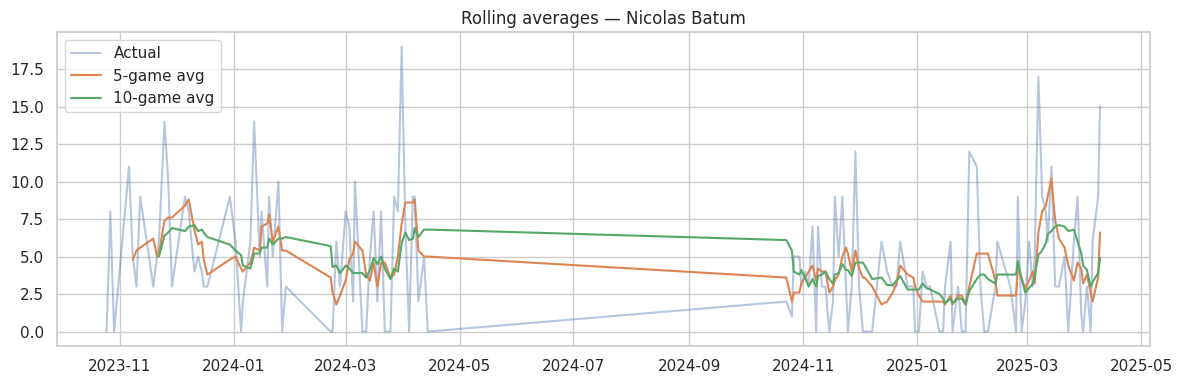

In [8]:
# Rolling avg preview for one player

player_df = df[df['full_name'] == df['full_name'].iloc[0]].copy()
player_df = player_df.sort_values('game_date')
player_df['rolling_5'] = player_df['points'].rolling(5).mean()
player_df['rolling_10'] = player_df['points'].rolling(10).mean()

plt.figure(figsize=(12, 4))
plt.plot(player_df['game_date'], player_df['points'], alpha=0.4, label='Actual')
plt.plot(player_df['game_date'], player_df['rolling_5'], label='5-game avg')
plt.plot(player_df['game_date'], player_df['rolling_10'], label='10-game avg')
plt.title(f"Rolling averages — {player_df['full_name'].iloc[0]}")
plt.legend()
plt.tight_layout()
plt.show()